In [36]:
from pathlib import Path
from mtpy import MTData, MT
from mtpy.modeling import StructuredGrid3D
import numpy as np

In [31]:
dx = 3000
line_stations = 10
n_frequencies = 23
utm_zone = "32611"
lower_left_corner = {"easting": 364000, "northing": 4200000}
upper_right_corner = {
    "easting": lower_left_corner["easting"] + dx * line_stations,
    "northing": lower_left_corner["northing"] + dx * line_stations,
}

md = MTData()
count = 1
for east in np.linspace(lower_left_corner["easting"], upper_right_corner["easting"], line_stations):
    for north in np.linspace(lower_left_corner["northing"], upper_right_corner["northing"], line_stations):
        mt_obj = MT()
        mt_obj.utm_epsg = utm_zone
        mt_obj.east = east
        mt_obj.north = north
        mt_obj.station = f"mt{count:03}"
        mt_obj.survey = "test_data"
        mt_obj.period = np.logspace(-3, 3, n_frequencies)
        mt_obj.impedance = np.random.rand(n_frequencies, 2, 2) + 1j*np.random.rand(n_frequencies, 2, 2)
        mt_obj.tipper = np.random.rand(n_frequencies, 1, 2) + 1j*np.random.rand(n_frequencies, 1, 2)
        md.add_station(mt_obj)
        count += 1
        



26:02:12T16:42:32 | WARNING | line:186 |mtpy.imaging.plot_stations | plot | Could not add base map because HTTPSConnectionPool(host='basemap.nationalmap.gov', port=443): Max retries exceeded with url: /arcgis/rest/services/USGSTopo/MapServer/tile/11/788/349 (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1032)')))


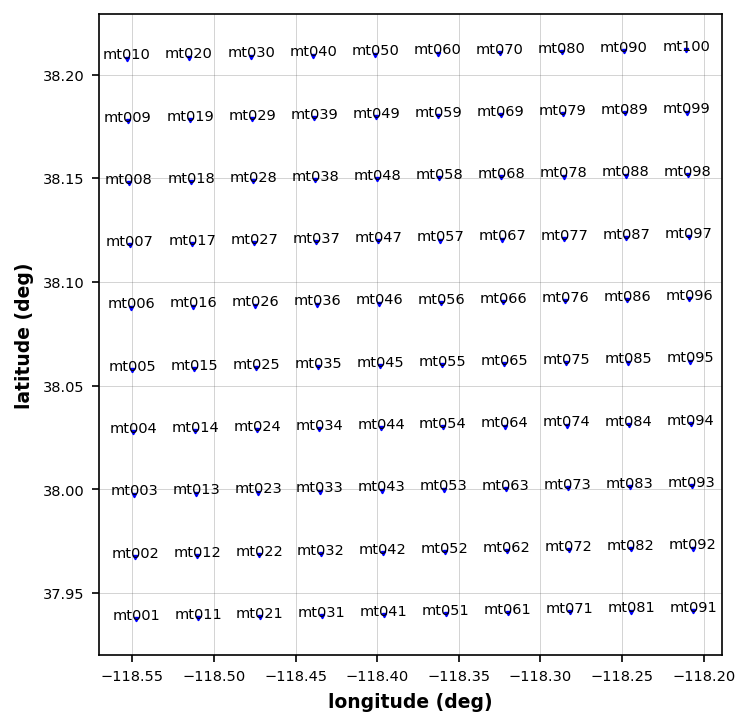

Plotting PlotStations

In [32]:
md.plot_stations()

In [16]:
df = md.to_modem(r"c:\Users\jpeacock\OneDrive - DOI\mt\ForwardModels\mt_grid_3km.dat")

26:02:12T16:32:49 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_xx 2300 times. Setting error as z_xx x 0.05.
26:02:12T16:32:49 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_xy 2300 times. Setting error as z_xy x 0.05.
26:02:12T16:32:49 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_yx 2300 times. Setting error as z_yx x 0.05.
26:02:12T16:32:49 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_yy 2300 times. Setting error as z_yy x 0.05.
26:02:12T16:32:49 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in t_zx 2300 times. Setting error as t_zx x 0.02.
26:02:12T16:32:49 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 

Structured3DMesh Model Object:
--------------------
	Number of stations = 100
	Mesh Parameter: 
		cell_size_east:    500
		cell_size_north:   500
		pad_east:          7
		pad_north:         7
		pad_num:           3
		z1_layer:          30
		z_target_depth:    30000
		n_layers:          50
		n_air_layers:      0
		res_initial_value: 100.0
	Dimensions: 
		e-w: 86
		n-s: 84
		z:   51 (without 7 air layers)
	Extensions: 
		e-w:  101500.0 (m)
		n-s:  100500.0 (m)
		0-z:  150973.0 (m)
--------------------
26:02:12T16:43:07 | WARNING | line:49 |mtpy.modeling.plots.plot_mesh | _plot_topography | Cannot find topography information, skipping
26:02:12T16:43:07 | WARNING | line:89 |mtpy.modeling.plots.plot_mesh | _plot_topography_ax2 | Cannot find topography information, skipping


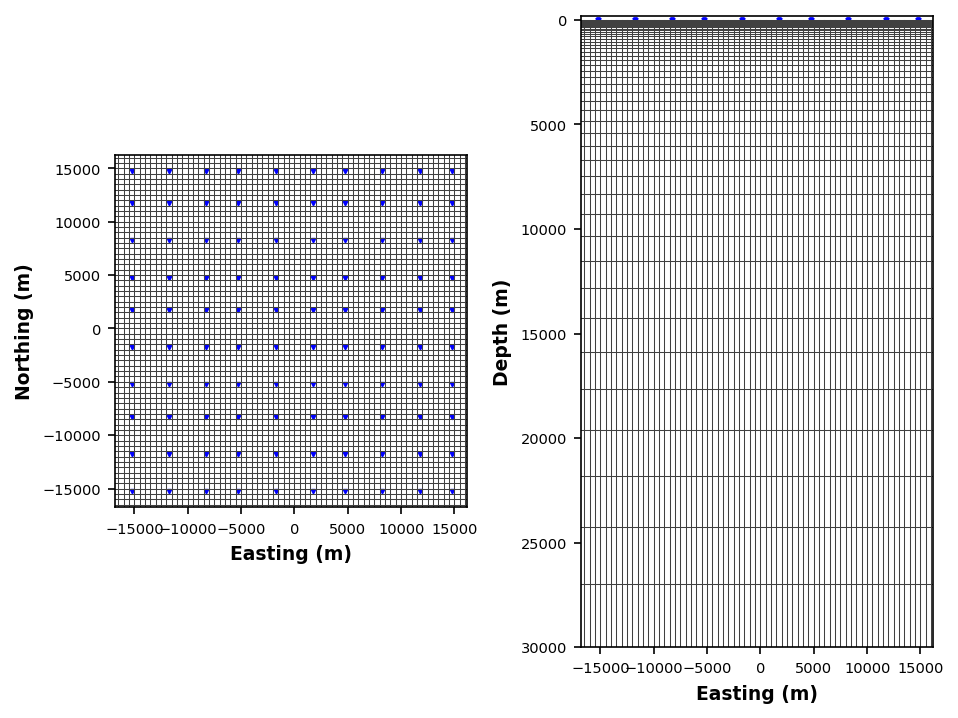

26:02:12T16:43:07 | INFO | line:830 |mtpy.modeling.structured_mesh_3d | to_modem | Wrote file to: c:\Users\jpeacock\OneDrive - DOI\mt\ForwardModels\modem_fwd_sm.rho


In [35]:
s = StructuredGrid3D(station_locations=md.station_locations)
s.center_point = md.center_point
s.cell_size_east = 500
s.cell_size_north = 500
s.n_layers = 50
s.z_target_depth = 30000
s.pad_z = 5
s.pad_stretch_v = 1.8
s.pad_stretch_h = 1.5
s.z1_layer = 30
s.make_mesh()
s.plot_mesh()
s.to_modem(r"c:\Users\jpeacock\OneDrive - DOI\mt\ForwardModels\modem_fwd_sm.rho")



In [34]:
md.center_stations(s)
md.to_modem(r"c:\Users\jpeacock\OneDrive - DOI\mt\ForwardModels\mt_grid_3km_c.dat")


26:02:12T16:43:01 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_xx 2300 times. Setting error as z_xx x 0.05.
26:02:12T16:43:01 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_xy 2300 times. Setting error as z_xy x 0.05.
26:02:12T16:43:01 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_yx 2300 times. Setting error as z_yx x 0.05.
26:02:12T16:43:01 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_yy 2300 times. Setting error as z_yy x 0.05.
26:02:12T16:43:01 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in t_zx 2300 times. Setting error as t_zx x 0.02.
26:02:12T16:43:01 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 

ModEM Data Object:
	Number of impedance stations: 100
	Number of tipper stations: 100
	Number of phase tensor stations: 100
	Number of periods:  23
	Period range (s):  
		Min: 0.001
		Max: 1000
	Rotation angle:     0
	Data center:        
		Latitude:   38.0747 deg 	Northing: 4215000.0000 m
		Longitude: -118.3795 deg 	Easting: 379000.0000 m
		Datum epsg: 4326			UTM epsg:   32611
		Elevation:  0.0 m
	Impedance data:     True
	Tipper data:        True
	Inversion Mode:   Full_Impedance, Full_Vertical_Components

In [37]:
md = MTData()
md.from_modem(r"c:\Users\jpeacock\OneDrive - DOI\mt\ForwardModels\ne_conductor_2_to_15km.dat")


26:02:13T10:40:05 | WARNING | line:784 |mtpy.imaging.plot_phase_tensor_maps | plot | Could not add base map because HTTPSConnectionPool(host='basemap.nationalmap.gov', port=443): Max retries exceeded with url: /arcgis/rest/services/USGSTopo/MapServer/tile/11/788/349 (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1032)')))


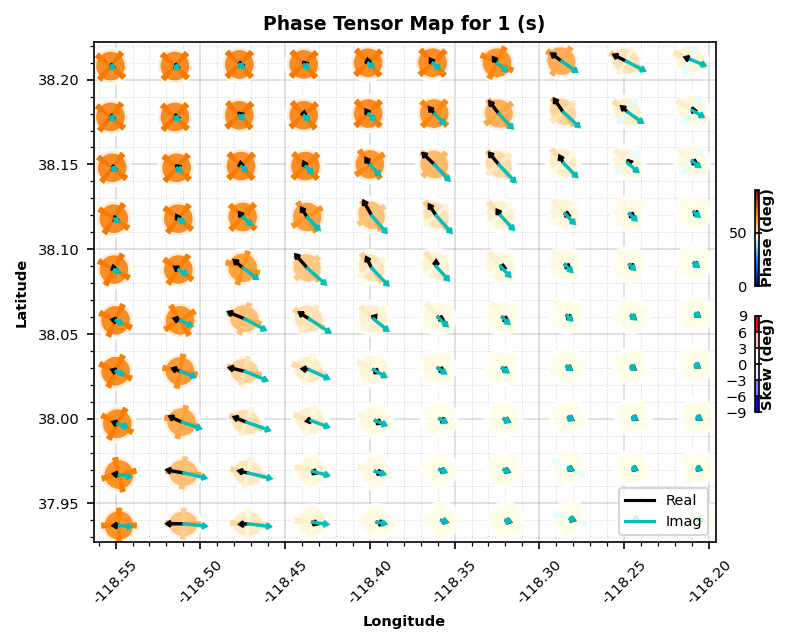

In [40]:
ptm = md.plot_phase_tensor_map(plot_tipper="yri", ellipse_size=.01, arrow_size=.1)

26:02:13T11:19:15 | WARNING | line:784 |mtpy.imaging.plot_phase_tensor_maps | plot | Could not add base map because HTTPSConnectionPool(host='basemap.nationalmap.gov', port=443): Max retries exceeded with url: /arcgis/rest/services/USGSTopo/MapServer/tile/11/788/349 (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1032)')))


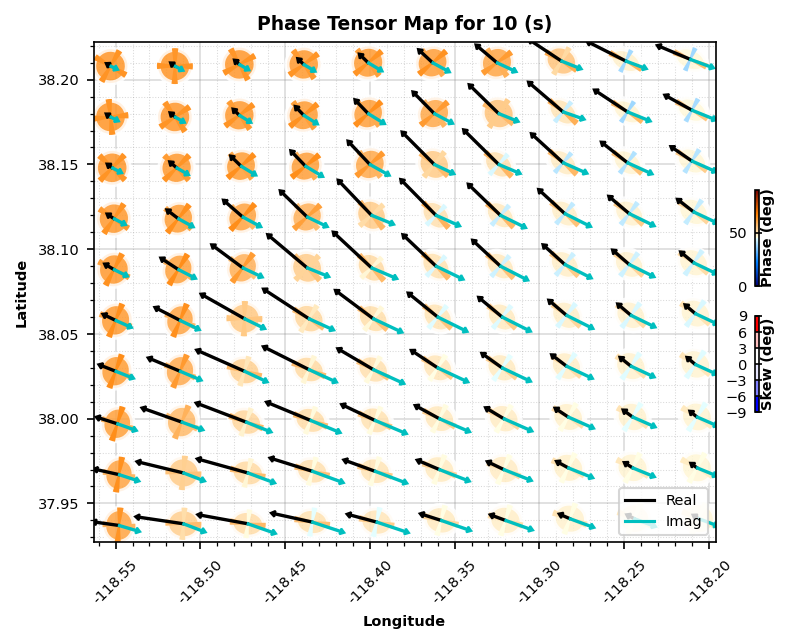

In [41]:
ptm.plot_period = 10
ptm.plot()

26:02:13T14:04:33 | WARNING | line:784 |mtpy.imaging.plot_phase_tensor_maps | plot | Could not add base map because HTTPSConnectionPool(host='basemap.nationalmap.gov', port=443): Max retries exceeded with url: /arcgis/rest/services/USGSTopo/MapServer/tile/11/788/349 (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1032)')))


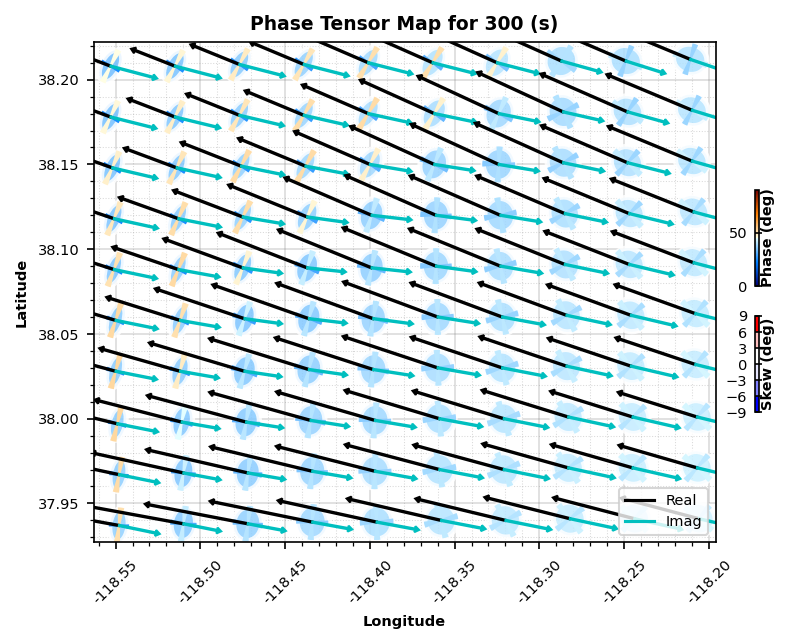

In [44]:
ptm.plot_period = 300
ptm.plot()

In [45]:
ptm.arrow_direction

1